In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pytest
import math
from ucimlrepo import fetch_ucirepo 
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Classe RTrainer

A classe RTrainer possui 4 métodos: inicialização, separação dos dados de treinamento, treinamento e por fim a predição do modelo

## Inicialização

É o construtor do nosso modelo, possui como parâmetros:

- Taxa de aprendizado -> passos do modelo em direção a convergência
- Ephocs -> iterações do modelo para o treinamento
- Erro -> erro que podemos usar para dizer que o modelo convergiu o suficiente para parar o treinamento antes de todas as iterações
- Logger -> opcional, mas serve para termos informações ao longo do treinamento

Além disso, possui atributos como parâmetros, médias e desvios padrões para treinamento/retorno do modelo

## Separação dos dados de treinamento

É um modulo que separa dos dados de treinamento em 3 partes: treinamento, teste e validação. Possui como argumentos: um dataframe de entrada, um de saída opcional, a coluna de output opcional e argumentos opcionais de normalização da entrada/output

Para lidar com uma maior gama de entrada de tipos de entrada, adicionei mais parâmetros, caso o usuário só passe um dataframe de entrada, preciso saber qual é a coluna de saída, do contrário retorno um erro. No caso de passar um dataframe de saída, junto com o de entrada pelos índices, fazendo com que cada linha seja a entrada/saída esperada.

Após isso, uso de uma função nativa do numpy para realizar a randomização dos dados, por isso precisamos juntar os dataframes, para garantir que a entrada correspondente seja a mesma da saída.

No próximo passo, temos um corte nos dados, os primeiros 70% são do conjunto de teste, os próximos 20% são do de validação, e por fim, os últimos 10% do conjunto de teste

Por fim, temos a normalização dos dados, dado o argumento opcional, que por padrão é aplicado a normalização z-score

- Por que normalizar os dados de saída? 
    
    No meu caso, o custo do modelo estava muito alto, o que de certa forma era o esperado para uma saída no formato que estava, por isso, inclusive que eu mantenho como um atributo da classe as médias e os desvios, para realizar a "desnormalização" dos dados quando estou retornando para o usuário. Além disso, para ser uma coisa mais auditável, eu não normalizo as saídas esperadas do modelo.


## Treinamento

Esse módulo é autoexplicativo por nome, recebe como argumentos os dataframes que vem da separação dos dados de treinamento.

De forma a aproveitar a biblioteca numpy que já realiza operações em matrizes de forma muito mais rápida, a primeira coisa que faço é transformar os dataframes dos argumentos em um array do tipo numpy. 

Os dados de entrada, X, vão ficar no formato (N, M), sendo N o número de linhas de entrada que temos e M o número de features. Enquanto que, os dados de previsão ficarão no formato (N,), ou seja, uma matriz unidimensional de N entradas, para garantir que vamos ter uma matriz unidimensional eu aplico a função .raven(). Dessa forma, o que temos inicialmente é:

X = $\begin{bmatrix} x_{1,1}& x_{1,2}& ...& x_{1,m} \\\ x_{2,1}& x_{2,2}& ...& x_{2,m}  \\\ ... \\\ x_{n,1}& x_{n,2}& ...& x_{n,m} \end{bmatrix}_{N,M}$ e Y = $\begin{bmatrix} y_1 \\\ y_2 \\\ ... \\\ y_n \end{bmatrix}_{N,}$

Por conta do $\theta_0$, uma das formas que eu achei para lidar com ele foi adicionar um pequeno vetor de 1s para garantir que consigamos realizar a multiplicação entre a matriz de entrada e o vetor de parâmetros. Dessa forma, atualizamos a nossa matriz para:

X = $\begin{bmatrix} 1& x_{1,1}& x_{1,2}& ...& x_{1,m} \\\ 1& x_{2,1}& x_{2,2}& ...& x_{2,m}  \\\ ... \\\ 1& x_{n,1}& x_{n,2}& ...& x_{n,m} \end{bmatrix}_{N,M+1}$

Após isso, inicializo o vetor de parâmetros

$\theta $ = $\begin{bmatrix} \theta_0 \\\ \theta_1 \\\ ... \\\ \theta_{m} \end{bmatrix}_{M+1,1}$

Onde $\theta_0, \theta_1, ..., \theta_{m}$ são inicializados com o valor 1.


Após a inicialização dos parâmetros, nós finalmente começamos o treinamento, a cada iteração, realizamos as seguintes ações:

- Multiplicação da matriz entrada de treinamento pelo vetor de parâmetros

$\begin{bmatrix} 1& x_{1,1}& x_{1,2}& ...& x_{1,m} \\\ 1& x_{2,1}& x_{2,2}& ...& x_{2,m}  \\\ ... \\\ 1& x_{n,1}& x_{n,2}& ...& x_{n,m} \end{bmatrix}_{N,M+1}$ * $\begin{bmatrix} \theta_0& \theta_1& ...& \theta_{m} \end{bmatrix}^T_{M+1,1}$ = $\begin{bmatrix} y_1 \\\ y_2 \\\ ... \\\ y_n \end{bmatrix}_{N,1}$

- Mutiplicação da matriz de validação pelo vetor de parâmetros

$\begin{bmatrix} 1& x^´_{1,1}& x^´_{1,2}& ...& x^´_{1,m} \\\ 1& x^´_{2,1}& x^´_{2,2}& ...& x^´_{2,m}  \\\ ... \\\ 1& x^´_{n,1}& x^´_{n,2}& ...& x^´_{n,m} \end{bmatrix}_{N,M+1}$ * $\begin{bmatrix} \theta_0& \theta_1& ...& \theta_{m} \end{bmatrix}^T_{M+1,1}$ = $\begin{bmatrix} ý_1 \\\ ý_2 \\\ ... \\\ ý_n \end{bmatrix}_{N,1}$
- Cálculo do custo utilizando a função:

$ J(\theta) = 1/(2*m) * \sum_{i=0}^{m}(ý- y)^2$
    
Onde m = número de entradas do conjunto de validação, ý é a saída do modelo e y é a saída esperada

- Cálculo do gradiente

Aplicando a fórmula apresentada no slide, temos que:

gradientes = (1/m) * $\begin{bmatrix} 1& 1& ...& 1& \\\ x^´_{1,1}& x^´_{2,1}& ...& x^´_{n,1}& \\\ x^´_{1,2}& x^´_{2,2}&  ...& x^´_{n,2} \\\ ... \\\ x^´_{1,m}& x^´_{2,m}& ...& x^´_{n,m} \end{bmatrix}_{M+1, N}$ * $\begin{bmatrix} ý_1 - y_1 \\\ ý_2 - y_2 \\\ ... \\\ ý_n - y_n \end{bmatrix}_{N,1}$

Onde aplicamos a transposta da matriz da entrada, dessa forma vamos ter a matriz resultado com a quantidade de features esperada -> M+1

- Atualização dos parâmetros

$\theta = \theta - \alpha * gradiente$

Onde $\alpha$ é a taxa de aprendizado


E por fim, temos a construção de um gráfico que mostra a relação entre custo x taxa de aprendizado e o retorno do vetor de parâmetros do modelo naquela base de dados

## Predição

Antes do modelo realizar os cálculos, ele adiciona novamente o coeficiente constante do $\theta_0$ para podermos realizar a multiplicação de matrizes sem problema

Após isso, apenas retornamos o resultado sem normalização. Aqui tanto faz se os dados são normalizados ou não, da forma como eu instancio não muda nada no resultado, por isso posso apenas retornar sem nenhuma validação

In [2]:
# TODO:
"""

Avaliação Quantitativa:

Calcular e reportar as métricas:
MAE (Mean Absolute Error)
MSE (Mean Squared Error)
MAPE (Mean Absolute Percentage Error)
As métricas devem ser implementadas em módulos ou classes próprias.
Comparar os erros de treinamento+desenvolvimento e teste.
Analisar se há overfitting ou underfitting, justificando os resultados.
Análise de Tempo de Treinamento:



."""

# TODO:

#       Testes Unitários: validar individualmente métodos como fit(), predict(), funções de erro, entre outros.
#       Testes Funcionais: validar o pipeline completo de treinamento e predição com conjuntos de dados simples.

'\n\nAvaliação Quantitativa:\n\nCalcular e reportar as métricas:\nMAE (Mean Absolute Error)\nMSE (Mean Squared Error)\nMAPE (Mean Absolute Percentage Error)\nAs métricas devem ser implementadas em módulos ou classes próprias.\nComparar os erros de treinamento+desenvolvimento e teste.\nAnalisar se há overfitting ou underfitting, justificando os resultados.\nAnálise de Tempo de Treinamento:\n\n\n\n.'

In [ ]:
class RTrainer:
    # Etapa de treinamento, é a mais simples, implementação está no slide
    def __init__(self, a, ephocs, erro=0, logger=False, media_entrada_treinamento=0, desvio_entrada_treinamento=1, media_previsao_treinamento=0, desvio_previsao_treinamento=1):
        """Construtor da classe RTrainer"""
        
        self.a = a # Taxa de aprendizado
        self.ephocs = ephocs # Quantidade de iterações do modelo
        self.erro = erro # Erro mínimo, um parâmetro adicional na hora de iterar, opcional
        self.logger = logger # Um log para acompanharmos algumas coisas que possam ser interessantes de serem observadas
        self.parametros = np.full(1, float('inf'))

        # Retorno predição
        self.media_entrada_treinamento = media_entrada_treinamento
        self.desvio_entrada_treinamento = desvio_entrada_treinamento
        self.media_previsao_treinamento = media_previsao_treinamento
        self.desvio_previsao_treinamento = desvio_previsao_treinamento

    def fit(self, dados_entrada_treinamento: pd.DataFrame, y_treinamento: pd.DataFrame) -> np.ndarray:
        """ Método que realiza o treinamento do modelo """

        if 'bias' not in dados_entrada_treinamento.columns:
            dados_entrada_treinamento.insert(0, column='bias', value=np.ones(dados_entrada_treinamento.shape[0]))
            
        x_treinamento = dados_entrada_treinamento.to_numpy()
        y_treinamento = y_treinamento.to_numpy().ravel()
        

        self.parametros = np.ones(x_treinamento.shape[1]) 
        historico_custo = []
        historico_lr = []

        for i in range(self.ephocs):

            y_pred = x_treinamento @ self.parametros  

            custo = 1/(2*(x_treinamento.shape[0])) * np.sum((y_pred - y_treinamento)**2) 
                
            historico_lr.append(self.a)
            historico_custo.append(custo)

            if custo < 0.0001:
                break

            gradientes = (1 / x_treinamento.shape[0]) * (x_treinamento.T @ (y_pred - y_treinamento))
            self.parametros = self.parametros - self.a * gradientes

        if self.logger:
            plt.figure(figsize=(8, 5))
            plt.scatter(historico_lr, historico_custo, c=range(len(historico_lr)), cmap='viridis')
            plt.xlabel('Taxa de Aprendizado (LR)')
            plt.ylabel('Custo')
            plt.title('Custo vs. Taxa de Aprendizado')
            plt.show()
        
        return self.parametros

    def predict(self, dados_predicao: np.ndarray) -> np.ndarray:
        """Método que realiza previsão do modelo"""

        if type(dados_predicao) == pd.Series:
            dados_predicao = pd.DataFrame(dados_predicao)
        if 'bias' not in dados_predicao.columns:
                dados_predicao.insert(0, column='bias', value=np.ones(dados_predicao.shape[0]))

        result = 0
        
        try:
            result = (self.parametros @ np.transpose(dados_predicao) * self.desvio_previsao_treinamento) + self.media_previsao_treinamento
        except:
            result = self.param

        return result
            


# Classe SplitData

Essa classe é a responsável pela separação e normalização dos dados, possuindo 3 métodos e um construtor padrão. Seus valores vem assim, porque caso precisemos realizar uma "desnormalização" em um dado que não foi normalizado, esses valores não afetarão no valor final

## PrepareDataFrame

Essa função prepara o dataframe, de forma a generalizar o comportamento dela, deixo opcional passarmos dois dataframes, um dataframe com uma coluna especificada para dizermos qual é o de saída. O que ela retorna é muito simples, o dataframe unificado e pronto para ser tratado e a coluna de saída.

## ValidationSplit

Como solicitado pelo professor, essa parte dos dados serão utilizados para ajustar a taxa de aprendizado. Se eu usasse o próximo método, na hora de juntar as bases de dados, teríamos um problema de dimensionalidade dos dados da normalização aplicada, por isso que eu separo ela aqui. Esse método separa apenas 30% dos dados destinados a validação para o ajuste dito anteriormente.

## TrainTestValidationSplit

Método que realiza o embaralhamento dos dados e um corte separado em conjunto de treino (80%) e teste (20%). O ValidationSplit segue na mesma linha que esse 

In [4]:
class SplitData:
    
    def __init__(self):    
        # Para normalização/desnormalização
        self.media_entrada_treinamento = 0
        self.desvio_entrada_treinamento = 1
        self.media_previsao_treinamento = 0
        self.desvio_previsao_treinamento = 1


    def prepare_dataframe(self, entrada: pd.DataFrame, saida: pd.DataFrame | None = None, output: str | None = None) -> pd.DataFrame:
        """ Prepara o dataframe para processamento nos dois próximos métodos """
        if saida is None and output is None:
            # Ver trowexception
            return("Erro: preciso de: ou um dataframe de saída ou de uma coluna referenciando o output no dataframe de entrada")

        coluna_Y = ''
        randomizando_dataframe = ''

        if output is None:
            coluna_Y = saida.columns[0]
            randomizando_dataframe = pd.concat([entrada, saida], axis=1)
        else:
            coluna_Y = output
            randomizando_dataframe = entrada.copy()

        return coluna_Y, randomizando_dataframe

    def validation_split(self, entrada: pd.DataFrame, saida: pd.DataFrame | None = None, output: str | None = None, normalizar: bool | None = None):
            """ Função que vai fazer o embaralhamento dos dados, para garantir que não haja nenhum viés no treinamento. Além disso, separamos apenas em validação. Vamos passar um único Dataframe e vamos separar aqui dentro"""

            coluna_Y, randomizando_dataframe = self.prepare_dataframe(entrada, saida, output)
            randomizando_dataframe = randomizando_dataframe.iloc[np.random.permutation(len(randomizando_dataframe))].reset_index(drop=True) # -> Usando o numpy para rearranjar os elementos, mantendo os índices normais

            corteValidacao = int(len(randomizando_dataframe)*0.3)       
            parteValidacao = randomizando_dataframe[:corteValidacao] # Primeiros 20% do dataframe

            colunas_X = []
            
            for i in randomizando_dataframe.columns:
                if i != coluna_Y:
                    colunas_X.append(i)
            
            X_val, y_val = parteValidacao[colunas_X].copy(), parteValidacao[coluna_Y].copy()

            if normalizar:
                
                X_val[colunas_X] = (X_val[colunas_X] - X_val[colunas_X].mean()) / X_val[colunas_X].std().replace(0, 1)
                y_val = (y_val - y_val.mean()) / y_val.std()

            return X_val, y_val

    
    def train_test_validation_split(self, entrada: pd.DataFrame, saida: pd.DataFrame | None = None, output: str | None = None, normalizar: bool | None = None, normalizar_output: bool | None = None):
            """ Função que vai fazer o embaralhamento dos dados, para garantir que não haja nenhum viés no treinamento. Além disso, separamos os dados em treinamento e teste. Vamos passar um único Dataframe e vamos separar aqui dentro"""

            coluna_Y, randomizando_dataframe = self.prepare_dataframe(entrada, saida, output)
            
            # Processo de "bagunçar" o dataframe
            randomizando_dataframe = randomizando_dataframe.iloc[np.random.permutation(len(randomizando_dataframe))].reset_index(drop=True) # -> Usando o numpy para rearranjar os elementos, mantendo os índices normais

            corteTeste = int(len(randomizando_dataframe)*0.80)

            parteTreinamento = randomizando_dataframe[:corteTeste] # Primeiros 80% do dataframe
            parteTeste = randomizando_dataframe[corteTeste:] # Últimos 20%

            # Separando os três dataframes:

            colunas_X = []

            for i in randomizando_dataframe.columns:
                if i != coluna_Y:
                    colunas_X.append(i)

            X_train, y_train = parteTreinamento[colunas_X].copy(), parteTreinamento[coluna_Y].copy()
            X_test, y_test = parteTeste[colunas_X].copy(),  parteTeste[coluna_Y].copy()

            # Caso queiramos normalizar os dados
            if normalizar:

                self.media_entrada_treinamento = X_train[colunas_X].mean()
                self.desvio_entrada_treinamento = X_train[colunas_X].std().replace(0, 1) # entender esse replace

                X_train[colunas_X] = (X_train[colunas_X] - self.media_entrada_treinamento) / self.desvio_entrada_treinamento
                X_test[colunas_X] = (X_test[colunas_X] - self.media_entrada_treinamento) / self.desvio_entrada_treinamento # Faz sentido normalizar -> modelo treinou com os dados normalizados

                if normalizar_output: 

                    self.media_previsao_treinamento = y_train.mean()
                    self.desvio_previsao_treinamento = y_train.std()

                    y_train = (y_train - self.media_previsao_treinamento) / self.desvio_previsao_treinamento

            return X_train, y_train, X_test, y_test

# Encontrando a melhor taxa de aprendizado

Por questões de praticidade e gosto, acabei optando por usar o Random Search para obtenção da melhor taxa de aprendizado. É um algoritmo simples, que gera um valor em uma escala logarítmica e usamos essa escala como a nossa taxa de aprendizado por algumas iterações de treinamento. Depois disso, utilizamos a mesma função de custo que usamos no treinamento e fazemos uma verificação simples de forma a separar a taxa de aprendizado que manteve o menor erro

In [5]:
def gera_taxa_aprendizado(log_min=-1, log_max=-4) -> float:

    return 10 ** np.random.uniform(log_min, log_max)

def random_serch(iteracoes: int, dados_entrada_treinamento: pd.DataFrame, y_treinamento: pd.DataFrame, ephocs=300) -> float:

    melhor_a = None
    menor_erro = float('inf')

    for i in range(iteracoes):

        a = gera_taxa_aprendizado()

        trainer = RTrainer(a=a, ephocs=ephocs)
        trainer.fit(dados_entrada_treinamento, y_treinamento)

        pred_val = trainer.predict(dados_entrada_treinamento)
        
        erro_val = np.mean((y_treinamento.to_numpy().ravel() - pred_val)**2)

        if erro_val < menor_erro:
            menor_erro = erro_val
            melhor_a = a

    return melhor_a

# Classe EvalutiveMetrics

Onde cada método é um tipo diferente de forma de avaliar o desempenho do modelo.

## MAE

Ou Mean Absolute Error, vai ser a média da soma dos valores absolutos

## MAPE

Ou Mean Absolute Percentage Error, vai ser a soma dos valores absolutos em porcentagem.

## MSE

Ou Mean Squared Error, vai ser a soma das predições do modelo pelo gabarito elevado ao quadrado


In [ ]:
class EvaluativeMetrics:
    # Instânciando a classe
    def __init__(self, y_pred: np.ndarray, y: np.ndarray):
        self.y_pred = y_pred
        self.y = y

    # Métrica MAE
    def MAE(self) -> float:
        """"""
        return 1/len(self.y_pred) * np.sum(abs(self.y_pred - self.y))

    # Métrica MAPE
    def MAPE(self) -> float:
        """"""
        return 100/len(self.y_pred) * np.sum(abs(self.y_pred - self.y)/self.y)

    # Métrica MSE:
    def MSE(self) -> float:
            """"""
            return 1/len(self.y_pred) * np.sum((self.y_pred - self.y)**2)



# Testes unitários

In [ ]:
def testando_fit_modelo(modelo: RTrainer, dados_entrada: pd.DataFrame, y: pd.DataFrame):
    
    try:
        pesos = modelo.fit(dados_entrada, dados_entrada)
    except Exception as e:
        pytest.fail(f"O fit do modelo falhou por: {e}")

    # Verificação se os pesos que estão saindo do modelo estão tipados como se esperado
    assert isinstance(pesos, np.ndarray)

    # Verificação da quantidade de pesos é n+1 da quantidade de colunas de entrada. Onde a quantidade de dimensões corresponde a quantidade de colunas e o shape corresponde a quatidade de parâmetros
    assert (dados_entrada.ndim + 1) == pesos.shape[0]

def teste_predict_modelo(dados_entrada: pd.DataFrame, modelo: RTrainer):

    # Modelo tentar prever sem ter sido treinado
    assert (modelo.predict(dados_entrada)) == np.full(1, float('inf')) # Inicializo isso como padrão no construtor, se ele nunca chamar o fit, isso aqui é esse valor mesmo

    assert isinstance(modelo.predict(dados_entrada), np.ndarray) # Tipo esperado do modelo
    

# Testes funcionais

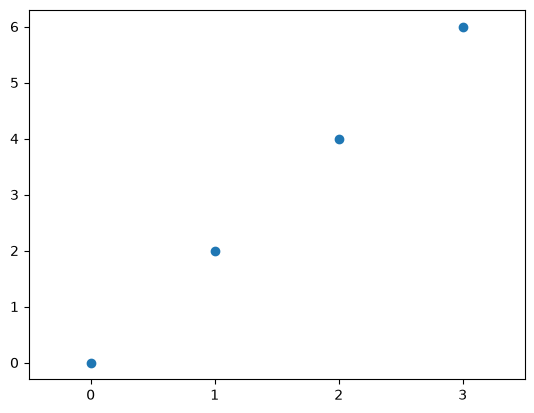

In [8]:
df_sintetico = pd.DataFrame({
                'x': range(4),
                'y': [i*2 for i in range(4)]
})

fig, ax = plt.subplots()
ax.scatter(df_sintetico['x'], df_sintetico['y'])
ax.set(xlim=(-0.5, 3.5), xticks=np.arange(0, 4))
plt.show()

In [9]:
# Warning: decisão ruim de projeto
treinamento = SplitData()

In [10]:
X_val_teste, y_val_teste,  = treinamento.validation_split(entrada=df_sintetico, output="y", normalizar=False)

In [11]:
# Usando apenas o conjunto de validação para achar a taxa de aprendizado
a = random_serch(100, X_val_teste, y_val_teste)

In [ ]:
X_train_teste, y_train_teste, X_prev_teste, y_prev_teste = treinamento.train_test_validation_split(entrada=df_sintetico, output="y", normalizar=False)

In [12]:
trainer = RTrainer(
    a = a,
    ephocs=10000,
    logger=True,
)

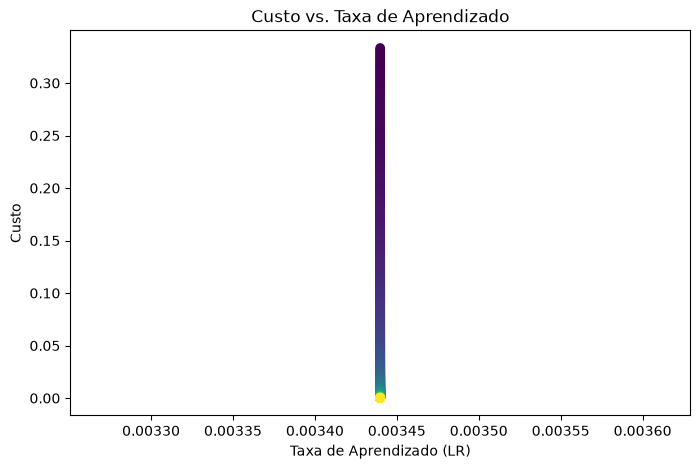

In [14]:
vetores_peso = trainer.fit(X_train_teste, y_train_teste)

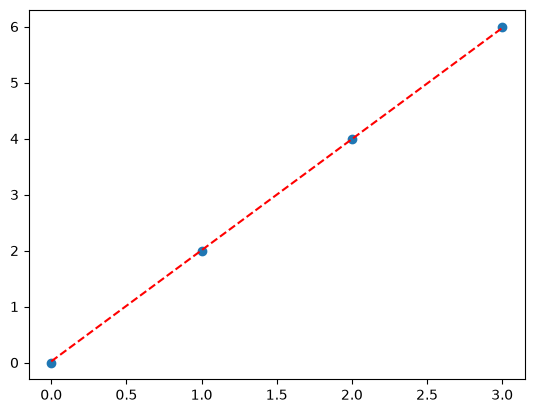

In [15]:
fig, ax = plt.subplots()

ax.scatter(df_sintetico['x'], df_sintetico['y'])

valores = trainer.parametros[0] + df_sintetico['x']*trainer.parametros[1]
ax.plot(df_sintetico['x'], valores, '--r')
plt.show()

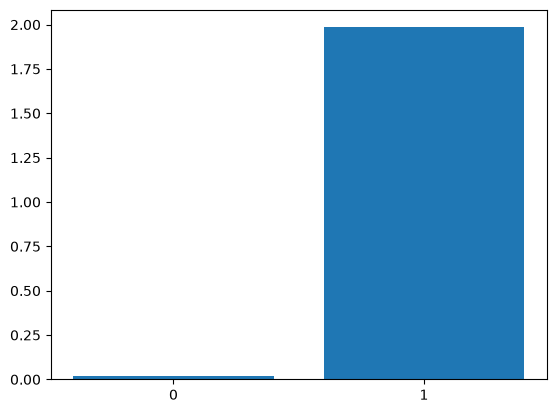

In [16]:
fig, ax = plt.subplots()

# TODO: forma de automatizar esse número de parâmetros + a altura
ax.bar(['0', '1'],trainer.parametros)

plt.show()

In [17]:
df = pd.read_csv("data/insurance.csv")

In [18]:
# Tratando alguns dados
def one_hot_sex(sex: str):
    if sex == "female":
        return 1
    else:
        return 0
    

In [19]:
df['sex'] = df['sex'].apply(one_hot_sex)

In [20]:
def one_hot_region(region: str):
    if region == 'southwest':
        return 1
    else:
        return 0

In [21]:
df['region'] = df['region'].apply(one_hot_region)
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,1,16884.92400
1,18,0,33.770,1,no,0,1725.55230
2,28,0,33.000,3,no,0,4449.46200
3,33,0,22.705,0,no,0,21984.47061
4,32,0,28.880,0,no,0,3866.85520
5,31,1,25.740,0,no,0,3756.62160
6,46,1,33.440,1,no,0,8240.58960
7,37,1,27.740,3,no,0,7281.50560
8,37,0,29.830,2,no,0,6406.41070
9,60,1,25.840,0,no,0,28923.13692


In [22]:
def one_hot_smoke(smoker: str):
    if smoker == 'yes':
        return 1
    else:
        return 0

In [23]:
df['smoker'] = df['smoker'].apply(one_hot_smoke)
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,1,16884.92400
1,18,0,33.770,1,0,0,1725.55230
2,28,0,33.000,3,0,0,4449.46200
3,33,0,22.705,0,0,0,21984.47061
4,32,0,28.880,0,0,0,3866.85520
5,31,1,25.740,0,0,0,3756.62160
6,46,1,33.440,1,0,0,8240.58960
7,37,1,27.740,3,0,0,7281.50560
8,37,0,29.830,2,0,0,6406.41070
9,60,1,25.840,0,0,0,28923.13692


In [24]:
treinamento = SplitData()

In [25]:
X_val, y_val = treinamento.validation_split(entrada=df, output="charges", normalizar=True)

In [26]:
a = random_serch(1000, X_val_teste, y_val_teste, ephocs=1000)

In [27]:
X_train, y_train, X_teste, y_teste = treinamento.train_test_validation_split(entrada=df, output="charges", normalizar=True)

In [28]:
trainer = RTrainer(
    a = a,
    ephocs=100000,
    logger=True,
    media_entrada_treinamento=treinamento.media_entrada_treinamento,
    desvio_entrada_treinamento=treinamento.desvio_entrada_treinamento,
    media_previsao_treinamento=treinamento.media_previsao_treinamento,
    desvio_previsao_treinamento=treinamento.desvio_previsao_treinamento
)

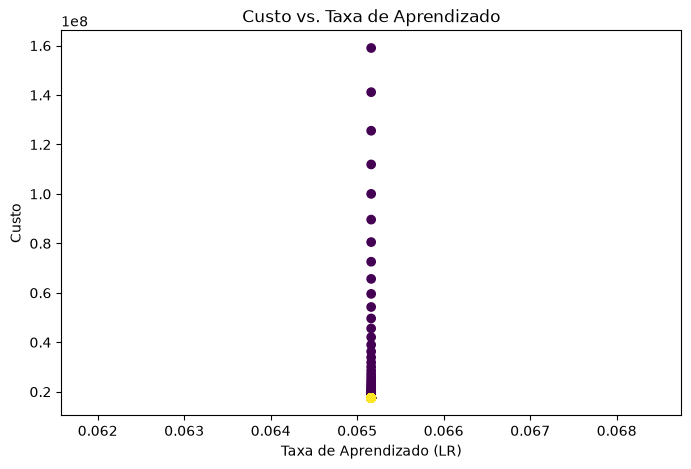

In [29]:
vetores_peso = trainer.fit(X_train, y_train)

In [30]:
trainer.predict(X_teste)

1070     5652.867241
1071     5512.886773
1072     9191.372141
1073    11697.044760
1074     2816.754293
            ...     
1333    -1272.009040
1334     8785.766776
1335     9556.999443
1336     2278.516613
1337    14273.240850
Length: 268, dtype: float64

In [31]:
print(y_teste)

1070     5385.33790
1071     5266.36560
1072     7358.17565
1073    10043.24900
1074    23082.95533
           ...     
1333     1242.81600
1334    10197.77220
1335     7345.08400
1336     2483.73600
1337    12643.37780
Name: charges, Length: 268, dtype: float64


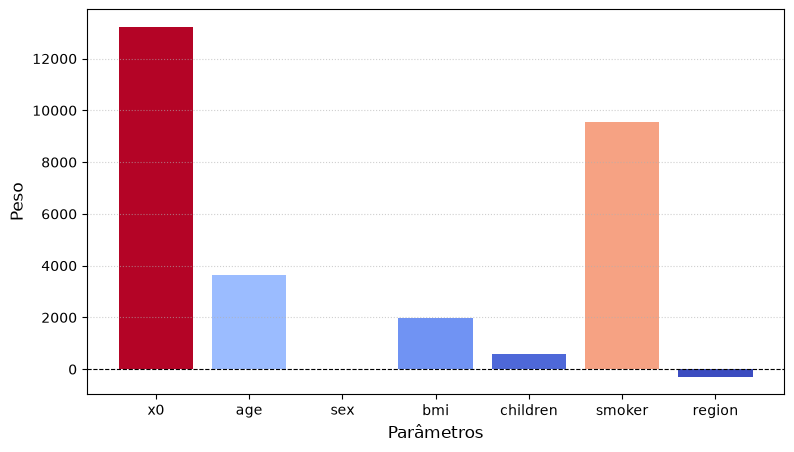

In [33]:
fig, ax = plt.subplots(figsize=(9, 5))

colunas = ['x0']

for x in df.columns:
    if x != 'charges':
        colunas.append(x)


norm = mcolors.Normalize(vmin=trainer.parametros.min(), vmax=trainer.parametros.max())
colors = cm.coolwarm(norm(trainer.parametros))

ax.bar(colunas, trainer.parametros, color=colors)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.grid(axis='y', linestyle=':', alpha=0.6)

ax.set_xlabel('Parâmetros', fontsize=12)
ax.set_ylabel('Peso', fontsize=12)

plt.show()